In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
df = pd.read_csv("netflix_cleaned.csv")

print("Dataset Loaded Successfully!")
print("Shape of Dataset:", df.shape)

# Display first 5 rows
print(df.head())

Dataset Loaded Successfully!
Shape of Dataset: (5332, 12)
  show_id     type                          title             director  \
0      s8    Movie                        Sankofa         Haile Gerima   
1      s9  TV Show  The Great British Baking Show      Andy Devonshire   
2     s10    Movie                   The Starling       Theodore Melfi   
3     s13    Movie                   Je Suis Karl  Christian Schwochow   
4     s25    Movie                          Jeans           S. Shankar   

                                                cast  \
0  Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
1  Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...   
2  Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...   
3  Luna Wedler, Jannis Niewöhner, Milan Peschel, ...   
4  Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...   

                                             country          date_added  \
0  United States, Ghana, Burkina Faso, United Kin...  September 24, 2021   
1       

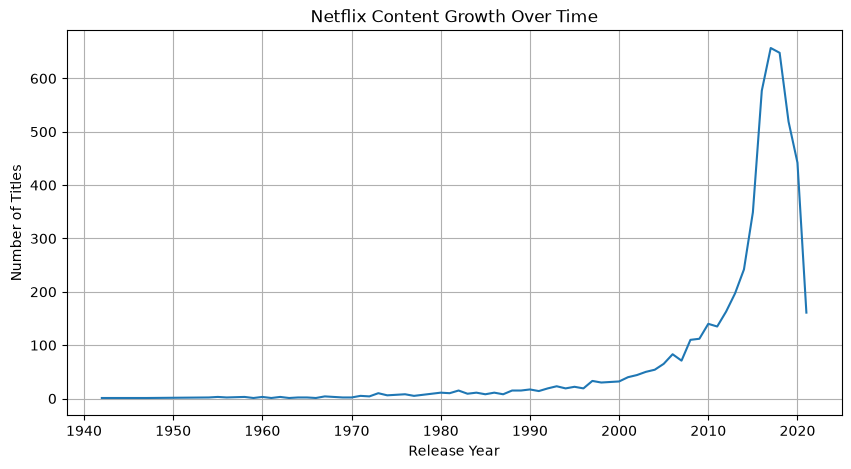

In [2]:
# 2. Netflix Content Growth Over Time
# ------------------------------------------
content_growth = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(content_growth.index, content_growth.values)
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()


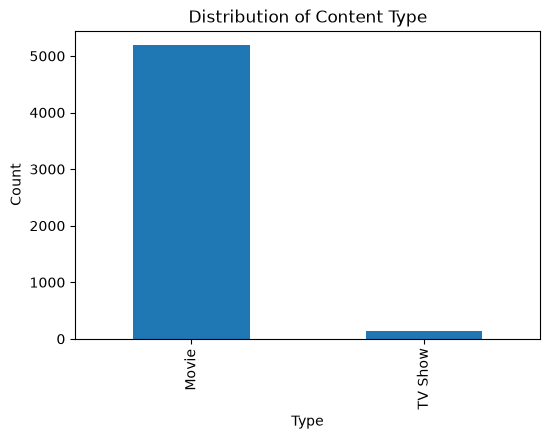

In [3]:
# 3. Distribution of Content Type
# ------------------------------------------
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar')
plt.title("Distribution of Content Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


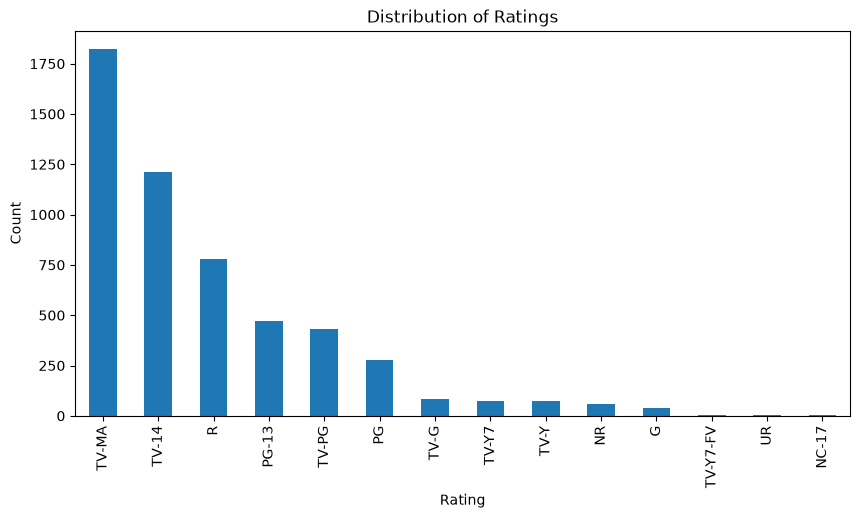

In [4]:
# 4. Distribution of Ratings
# ------------------------------------------
plt.figure(figsize=(10,5))
df['rating'].value_counts().plot(kind='bar')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

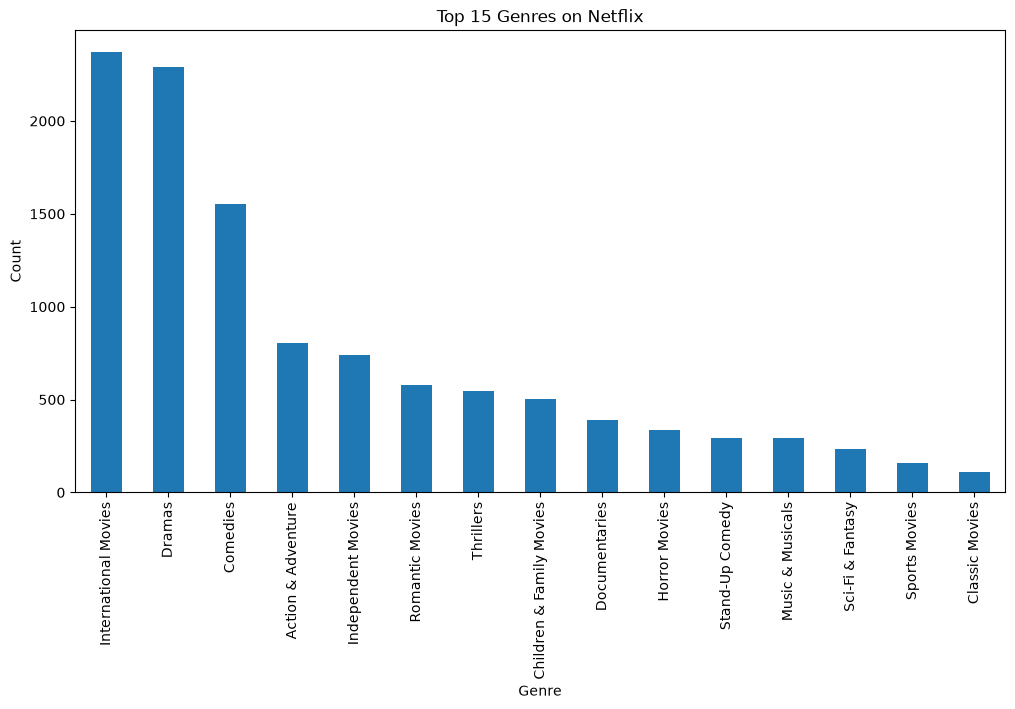

In [ ]:
# 5. Genre Distribution
# ------------------------------------------
genre_counts = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
)

plt.figure(figsize=(12,6))
genre_counts.head(15).plot(kind='bar')
plt.title("Top 15 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

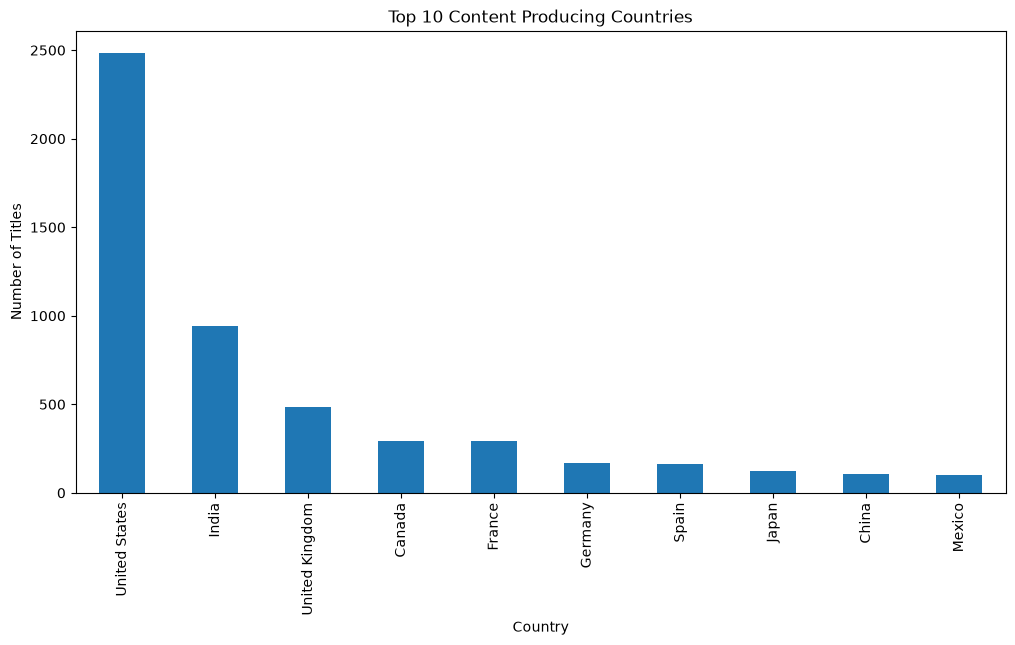

In [6]:
# 6. Country-Level Content Contribution
# ------------------------------------------
country_counts = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

plt.figure(figsize=(12,6))
country_counts.head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()


Content Length Category:
Content_Length_Category
Medium Movie    3878
Long Movie      1065
Short Movie      242
TV Show          147
Name: count, dtype: int64


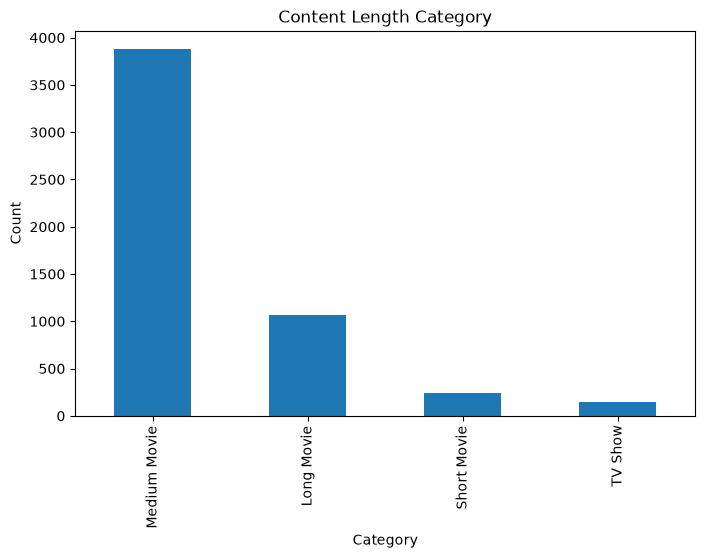

In [7]:
# 7. Content Length Category
# ------------------------------------------
def categorize_duration(duration):

    duration = str(duration)

    if "min" in duration:

        minutes = int(duration.split()[0])

        if minutes < 60:
            return "Short Movie"

        elif minutes <= 120:
            return "Medium Movie"

        else:
            return "Long Movie"

    return "TV Show"

df['Content_Length_Category'] = df['duration'].apply(categorize_duration)

print("\nContent Length Category:")
print(df['Content_Length_Category'].value_counts())

# Visualization
plt.figure(figsize=(8,5))
df['Content_Length_Category'].value_counts().plot(kind='bar')
plt.title("Content Length Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()



Original vs Licensed:
Original_vs_Licensed
Licensed    5331
Original       1
Name: count, dtype: int64


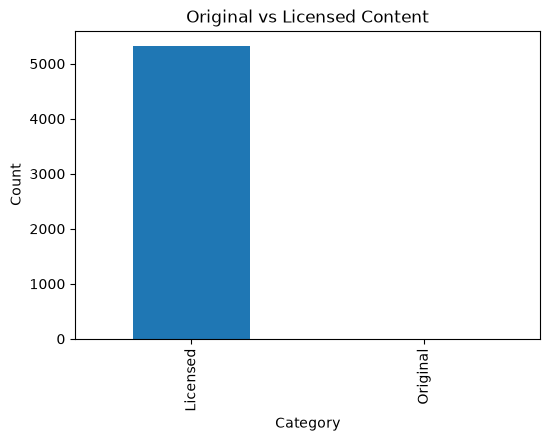

In [8]:
# 8. Original vs Licensed
# ------------------------------------------
df['Original_vs_Licensed'] = np.where(
    df['title'].str.contains('Netflix', case=False, na=False),
    'Original',
    'Licensed'
)

print("\nOriginal vs Licensed:")
print(df['Original_vs_Licensed'].value_counts())

# Visualization
plt.figure(figsize=(6,4))
df['Original_vs_Licensed'].value_counts().plot(kind='bar')
plt.title("Original vs Licensed Content")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [9]:
# 9. Save Updated Dataset
# ------------------------------------------
df.to_csv("netflix_feature_engineered.csv", index=False)

print("\nMilestone 2 Completed Successfully!")
print("Updated dataset saved as 'netflix_feature_engineered.csv'")


Milestone 2 Completed Successfully!
Updated dataset saved as 'netflix_feature_engineered.csv'
